# Credit card fraud detection & Fraud Analytics Dashboard

#1 . Import Libraries

In [25]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

#2. Load Dataset

In [20]:
df = pd.read_csv("../Dataset/creditcard.csv")

#3. Business Understanding 

### Problem Statement
BAnks process millions of credit card transactions every day .Some of these transactions are fraduluent , resulting in financial losses.
The objective of this project is to develop a machine learning model that can identify fraduluent transactions and provide business insights through data anaysis.      

##4.Dataa Understanding

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.shape


(284807, 31)

In [6]:
df.info

<bound method DataFrame.info of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599  

##5. Data cleaning

In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(1081)

In [24]:
df = df.drop_duplicates()

##6 . Exploratory Data Analysis(EDA)

###6.1 Class Distribution

In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [10]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

###6.2 Fraud Percentage 

In [12]:
fraud_percentage = (df['Class'].sum() / len(df))*100
print(fraud_percentage)

0.1727485630620034


Only 0.172% of all transactions are fraudulent.

In [13]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [11]:
import matplotlib.pyplot as plt 
import seaborn as sns 

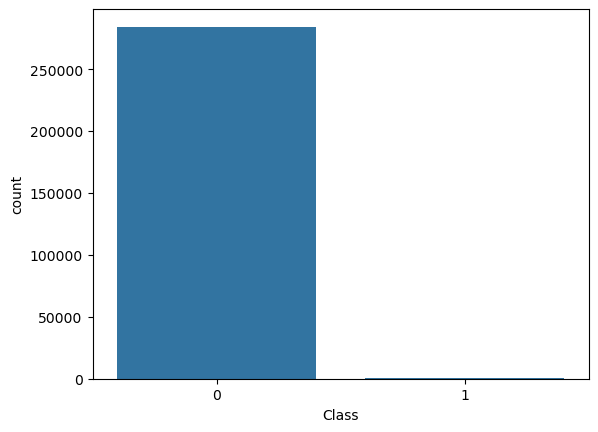

In [15]:
sns.countplot(x='Class', data = df)
plt.show()

###6.3 Amount Analysis

In [16]:
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

## Transaction Amount Analysis

- The average transaction amount is 88.35.
- The median transaction amount is 22.
- The maximum transaction amount is 25,691.16.
- This indicates the presence of high-value outlier transactions.

###6.4 Groupby analysis

In [3]:
df.groupby('Class')['Amount'].mean()

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

In [4]:
df.groupby('Class')['Amount'].agg(['count','mean','min','max'])

,count,mean,min,max
Class,,,,
0,284315,88.291022,0.0,25691.16
1,492,122.211321,0.0,2125.87


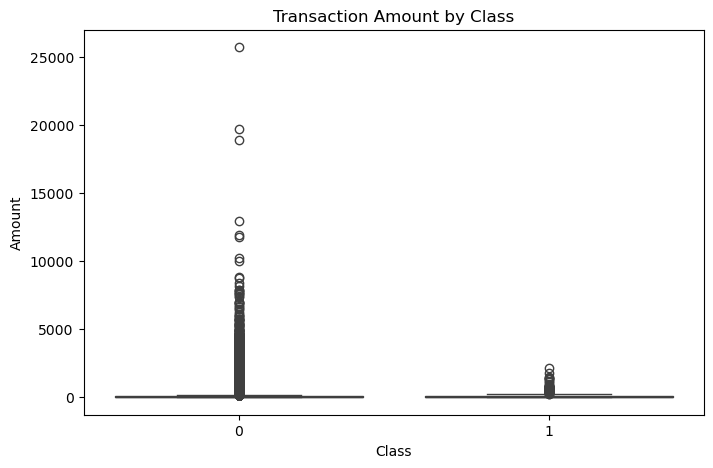

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.boxplot(x='Class',y='Amount',data=df)
plt.title('Transaction Amount by Class')
plt.show()

## Fraud vs Genuine Transaction Amount Analysis

The average transaction amount for genuine transactions is 88.29.

The average transaction amount for fraudulent transactions is 122.21.

This indicates that fraudulent transactions tend to involve higher transaction values compared to genuine transactions.

However, transaction amount alone is not sufficient to identify fraud and should be analyzed alongside other features.

In [11]:
df.groupby('Class')['Amount'].count()

Class
0    284315
1       492
Name: Amount, dtype: int64

In [12]:
df.groupby('Class')['Amount'].sum()

Class
0    25102462.04
1       60127.97
Name: Amount, dtype: float64

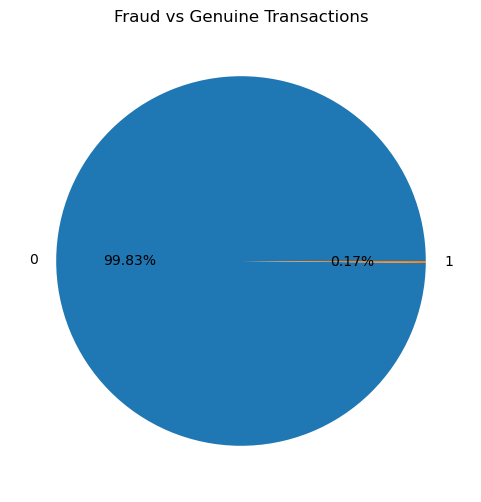

In [14]:
plt.figure(figsize=(6,6))
df['Class'].value_counts().plot(
    kind='pie',
    autopct='%1.2f%%'
)
plt.title('Fraud vs Genuine Transactions')
plt.ylabel('')
plt.show()

## Fraud Transaction Summary

- The dataset contains 284,315 genuine transactions and 492 fraudulent transactions.
- Fraudulent transactions represent only 0.17% of all transactions.
- The total amount associated with fraudulent transactions is 60,127.97.
- Genuine transactions account for the vast majority of transaction volume and value.
- The dataset is highly imbalanced, making fraud detection a challenging machine learning problem.

###6.5 Time Analysis

In [15]:
df['Time'].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

###6.6 Histogram

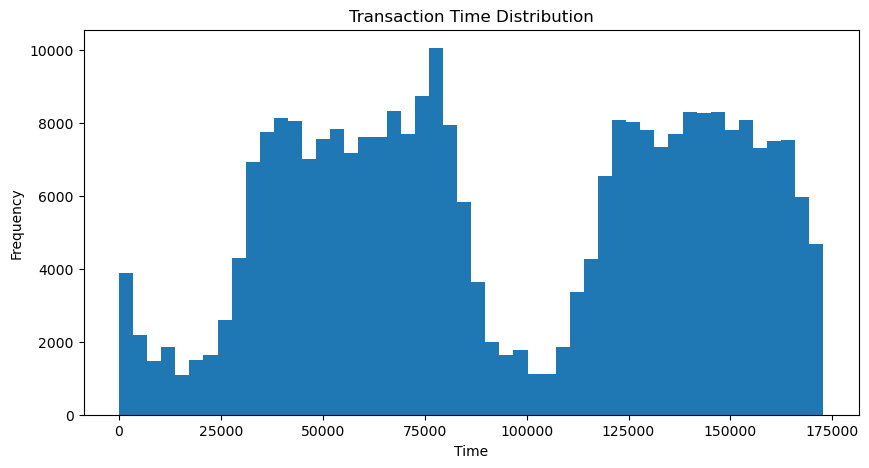

In [16]:
plt.figure(figsize=(10,5))
plt.hist(df['Time'],bins=50)
plt.title('Transaction Time Distribution')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

## Time Analysis

The Time feature represents the number of seconds elapsed since the first transaction in the dataset.

The transactions span approximately 172,792 seconds, which is about 48 hours (2 days).

This feature can help identify whether fraudulent transactions occur more frequently during specific periods.

In [17]:
df.groupby('Class')['Time'].mean()

Class
0    94838.202258
1    80746.806911
Name: Time, dtype: float64

###6.7 Box plot

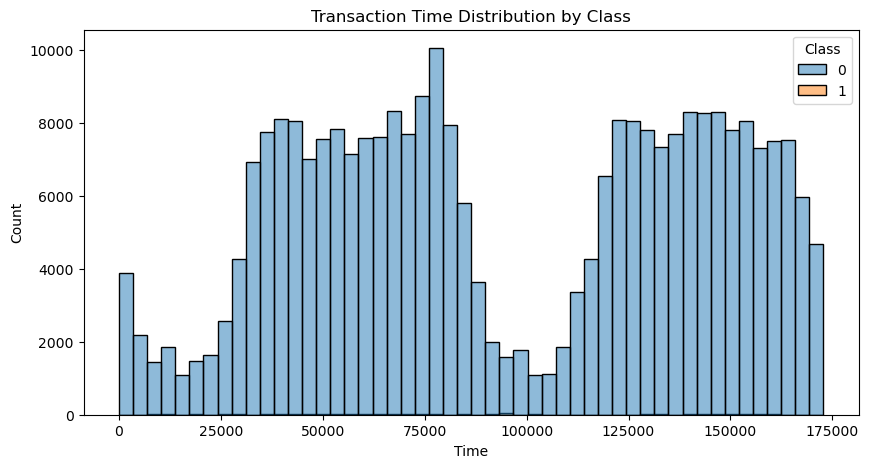

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(data=df,x='Time',hue='Class',bins=50)
plt.title('Transaction Time Distribution by Class')
plt.show()

## Duplicate Analysis

The dataset contains 1,081 duplicate records.

Duplicate transactions may lead to incorrect transaction counts and biased fraud statistics.

These duplicates should be investigated and handled appropriately before model development.

In [37]:
df.shape

(283726, 31)

In [38]:
df.duplicated().sum()

np.int64(0)

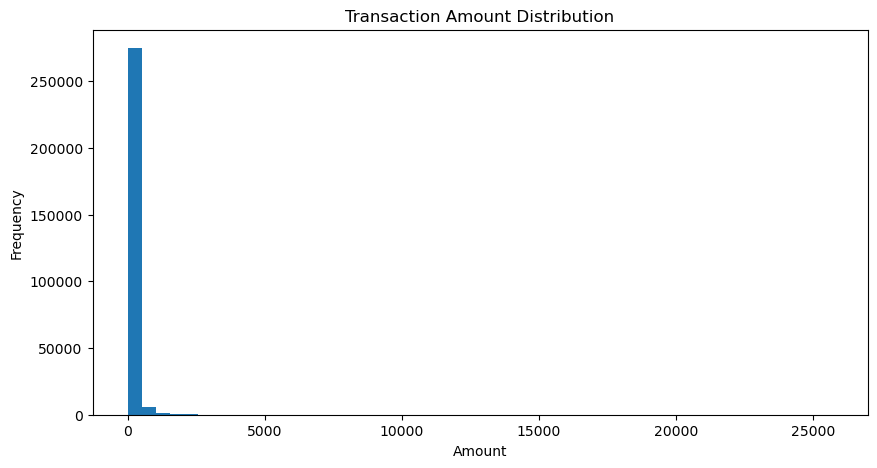

In [39]:
plt.figure(figsize=(10,5))
plt.hist(df['Amount'],bins=50)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

## Transaction Amount Distribution

The transaction amount distribution is highly right-skewed.

Most transactions are of relatively small value, while a small number of transactions involve very large amounts.

These high-value transactions create a long right tail and increase the average transaction amount.

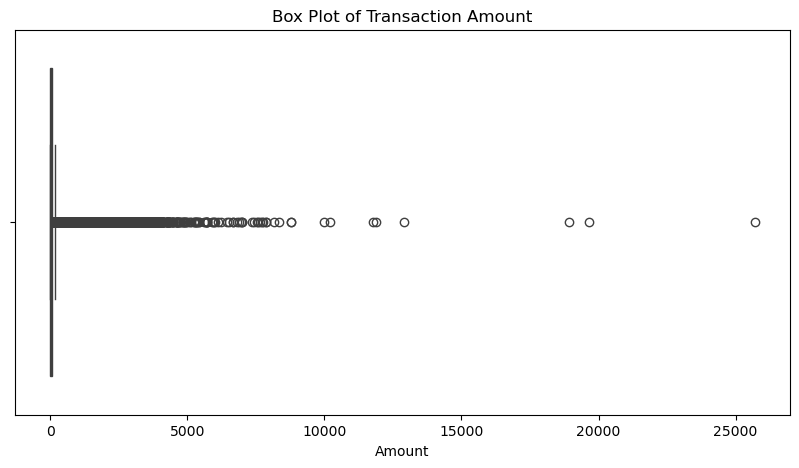

In [40]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Amount'])
plt.title('Box Plot of Transaction Amount')
plt.show()

## Outlier Analysis

The box plot revealed a significant number of outliers in the Amount feature.

Most transactions are concentrated within a relatively small range, while a small number of transactions involve very high values.

These outliers may represent unusual customer behavior and could be useful for fraud detection analysis.

###6.8 Correlation Heatmap

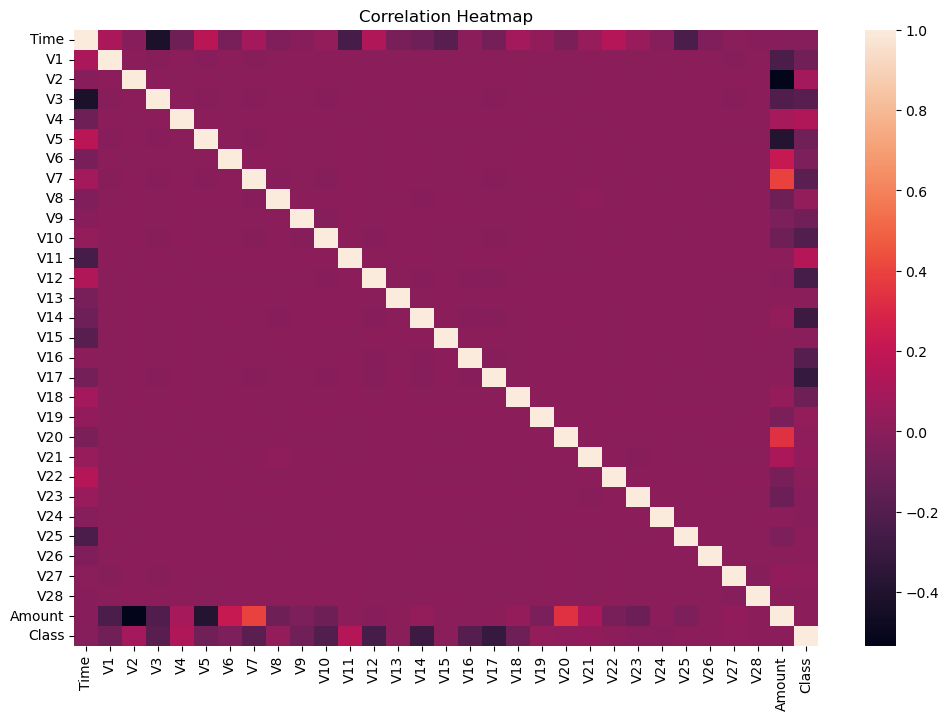

In [41]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr())
plt.title('Correlation Heatmap')
plt.show()

In [16]:
df.corr()['Class'].sort_values()

V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V6       -0.043915
Time     -0.012359
V24      -0.007210
V23      -0.006333
V13      -0.003897
V15      -0.003300
V25       0.003202
V26       0.004265
V22       0.004887
Amount    0.005777
V28       0.009682
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V2        0.084624
V4        0.129326
V11       0.149067
Class     1.000000
Name: Class, dtype: float64

## Correlation Analysis

Correlation analysis was performed to identify features associated with fraudulent transactions.

The strongest correlations with the target variable (Class) were observed for:

- V17 (-0.313)
- V14 (-0.293)
- V12 (-0.251)
- V10 (-0.207)
- V16 (-0.187)

The Amount feature showed a very weak correlation with fraud, indicating that transaction amount alone is not a reliable predictor of fraudulent activity.

##7 Feature Engineering

In [42]:
X = df.drop('Class', axis=1)
Y = df['Class']
print(x.shape)
print(y.shape)

NameError: name 'x' is not defined

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X_train, x_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

NameError: name 'X' is not defined

In [18]:
print(X_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(227845, 30)
(56962, 30)
(227845,)
(56962,)


In [19]:
y_train.value_counts()
y_test.value_counts()

Class
0    56864
1       98
Name: count, dtype: int64

In [20]:
y_train.value_counts()

Class
0    227451
1       394
Name: count, dtype: int64

1. Train-Test Split ✅
2. Train First Model
3. Make Predictions
4. Evaluate Model
5. Understand Confusion Matrix
6. Improve Model

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train , y_train)

NameError: name 'X_train' is not defined

##8 Feature Scaling

In [27]:
from sklearn.preprocessing import StandardScaler

In [16]:
scaler = StandardScaler()

In [29]:
X_train_scaled = scaler.fit_transform(X_train)

NameError: name 'X_train' is not defined